In [1]:
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import keras
import zipfile

2026-06-01 08:54:32.815874: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780304072.999718      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780304073.055640      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780304073.514795      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780304073.514833      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780304073.514838      58 computation_placer.cc:177] computation placer alr

In [2]:
sns.set(rc={'figure.figsize': (10, 10), 'axes.grid': False})

# Получение данных

In [3]:
PATH = '/kaggle/input/datasets/lutiiii/cells-segmentation'

# Моделька

In [4]:
def get_name(name: str | None, suffix: str, sep: str = '_') -> str | None:
    return name + sep + suffix if name else None

In [5]:
def conv_block(
    x: keras.KerasTensor,
    features: int,
    kernel_size: int,
    activation: str = 'relu',
    name: str | None = None
) -> keras.KerasTensor:

    x = keras.layers.Conv2D(features, kernel_size, padding='same', name=get_name(name, 'conv'))(x)
    x = keras.layers.LayerNormalization(name=get_name(name, 'norm'))(x)
    x = keras.layers.Activation(activation, name=get_name(name, 'activation'))(x)

    return x

In [6]:
def unet_block(
    x: keras.KerasTensor,
    features: int,
    depth: int,
    block_size: int,
    activation: str = 'relu',
    conv_pool: bool = False,
    conv_upsample: bool = True
) -> keras.KerasTensor:
    block_name = f'unet_block_{depth}'
    for i in range(block_size):
        x = y = conv_block(x, features, kernel_size=3, activation=activation, name=get_name(block_name, f'down_block_{i}'))
        
    if depth == 0:
        x = keras.layers.Dropout(0.2, name=get_name(block_name, 'dropout'))(x)
        return x
        
    if conv_pool:
        x = keras.layers.Conv2D(features, 2, strides=2, name=get_name(block_name, 'pool_conv'))(x)
    else:
        x = keras.layers.MaxPool2D(name=get_name(block_name, 'pool_max'))(x)
    
    x = unet_block(x, features * 2, depth - 1, block_size, activation, conv_pool)
    if conv_upsample:
        x = keras.layers.Conv2DTranspose(features, 2, strides=2, name=get_name(block_name, 'upsample_conv'))(x)
    else:
        x = keras.layers.UpSampling2D(name=get_name(block_name, 'upsample'))(x)
        
    x = keras.layers.Concatenate(name=get_name(block_name, 'concat'))([x, y])

    for i in range(block_size):
        x = conv_block(x, features, kernel_size=3, activation=activation, name=get_name(block_name, f'up_block_{i}'))

    return x

In [7]:
def unet(
    n_classes: int,
    features: int,
    name: str | None = 'unet',
    top_activation: str | None = None,
    conv_pool: bool = False,
    conv_upsample: bool = True
) -> keras.Model:
    
    x = inputs = keras.layers.Input((None, None, 3), name=get_name(name, 'Input'))
    x = unet_block(x, features, 4, 2, activation='silu', conv_pool=conv_pool, conv_upsample=conv_upsample)
    x = keras.layers.Conv2D(n_classes, 1,  name=get_name(name, 'last_conv'), activation=top_activation)(x)

    return keras.models.Model(inputs=inputs, outputs=x, name=name)

# Лоссы

In [8]:
class CategoricalDiceLoss(keras.losses.Loss):
    def __init__(self, smoothing: float = 1., *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.smoothing = smoothing
    
    def call(self, y_true: keras.KerasTensor, y_pred: keras.KerasTensor) -> keras.KerasTensor:
        y_pred = keras.ops.softmax(y_pred, axis=-1)
        y_true = keras.ops.one_hot(y_true, y_pred.shape[-1])
        intersection = keras.ops.sum(y_true * y_pred, axis=(1, 2))
        dsc = (intersection + self.smoothing) * 2 / (keras.ops.sum(y_true, axis=(1, 2)) + keras.ops.sum(y_pred, axis=(1, 2)) + self.smoothing)
        
        return 1 - keras.ops.mean(dsc, axis=-1)
        
    def get_config(self):
        config = super().get_config()
        config['smoothing'] = self.smoothing
        return config

In [9]:
class CategoricalFocalLoss(keras.losses.Loss):
    def __init__(self, alpha: float = 0.25, gamma: float = 2, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha = alpha
        self.gamma = gamma
        self.loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction="none")
    
    def call(self, y_true: keras.KerasTensor, y_pred: keras.KerasTensor) -> keras.KerasTensor:
        log_p = -self.loss(y_true, y_pred)
        p = keras.ops.exp(log_p)
        return -self.alpha * keras.ops.power(1 - p, self.gamma) * log_p

    def get_config(self):
        config = super().get_config()
        config['alpha'] = self.alpha
        config['gamma'] = self.gamma
        return config

In [10]:
class CategoricalFocalDiceLoss(keras.losses.Loss):
    def __init__(self, alpha: float = 0.75, gamma: float = 2, smoothing: float = 1., dice_coeff=0.4, focal_coeff=0.6,  *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing
        self.focal_coeff = focal_coeff
        self.dice_coeff = dice_coeff
        self.focal = CategoricalFocalLoss(alpha=alpha, gamma=gamma)
    
    def call(self, y_true: keras.KerasTensor, y_pred: keras.KerasTensor) -> keras.KerasTensor:
        focal = keras.ops.mean(self.focal(y_true, y_pred))

        y_pred = keras.ops.softmax(y_pred, axis=-1)
        y_true = keras.ops.one_hot(keras.ops.cast(y_true, 'int32'), keras.ops.shape(y_pred)[-1])
        
        intersection = keras.ops.sum(y_true * y_pred, axis=(1, 2))
        dsc = (intersection + self.smoothing) * 2 / (keras.ops.sum(y_true, axis=(1, 2)) + keras.ops.sum(y_pred, axis=(1, 2)) + self.smoothing)
        dice = 1 - keras.ops.mean(dsc)

        return self.focal_coeff * focal + self.dice_coeff * dice
    
    def get_config(self):
        config = super().get_config()
        config["alpha"] = self.alpha
        config["gamma"] = self.gamma
        config["smoothing"] = self.smoothing
        config["focal_coeff"] = self.focal_coeff
        config["dice_coeff"] = self.dice_coeff
        return config

# Датасет

In [11]:
def flips(
    image: np.ndarray,
    mask: np.ndarray,
) -> list[tuple[np.ndarray, np.ndarray]]:
    results = []
    for k in range(4):
        img_rot  = np.rot90(image, k)
        mask_rot = np.rot90(mask, k)
        results.append((img_rot.copy(), mask_rot.copy()))
        results.append((np.fliplr(img_rot).copy(), np.fliplr(mask_rot).copy()))
    return results

In [12]:
def sliding_horizontal(
    image: np.ndarray,
    mask: np.ndarray,
    strip_height: int = 128,
    stride: int = 64,
    min_content: float = 0.0,
) -> list[tuple[np.ndarray, np.ndarray]]:
    h, w = image.shape[:2]
    results = []
 
    for y in range(0, h - strip_height + 1, stride):
        img_strip  = image[y:y+strip_height, :].copy()
        mask_strip = mask [y:y+strip_height, :].copy()
 
        if mask_strip.mean() < min_content:
            continue
        
        img_strip  = cv2.resize(img_strip, (w, h))
        mask_strip = cv2.resize(mask_strip.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST).astype(np.int32)
        
        results.append((img_strip, mask_strip))
 
    return results

In [13]:
def sliding_vertical(
    image: np.ndarray,
    mask: np.ndarray,
    strip_width: int = 128,
    stride: int = 64,
    min_content: float = 0.0,
) -> list[tuple[np.ndarray, np.ndarray]]:
    h, w = image.shape[:2]
    results = []
 
    for x in range(0, w - strip_width + 1, stride):
        img_strip  = image[:, x:x+strip_width].copy()
        mask_strip = mask [:, x:x+strip_width].copy()
 
        if mask_strip.mean() < min_content:
            continue
 
        img_strip  = cv2.resize(img_strip, (w, h))
        mask_strip = cv2.resize(mask_strip.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST).astype(np.int32)
 
        results.append((img_strip, mask_strip))
 
    return results

In [14]:
class SegmentationDataset(keras.utils.PyDataset):
    def __init__(
        self,
        IMG_PATH: str,
        batch_size: int = 8,
        flips_act: bool = False,
        h_strips: bool = False,
        v_strips: bool = False,
        strip_height: int = 128,
        strip_width: int = 128,
        strip_stride: int = 64,
        min_content: float = 0.1,
        shuffle: bool = False,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.batch_size = batch_size

        path = Path(IMG_PATH)
        paths = sorted(p for p in path.glob("[0-9]*.png") if "_outline" not in p.stem)

        pairs = [(p, path / f"{p.stem}_outline.png") for p in paths]

        originals = [(self._load_image(lp), self._load_mask(lm)) for lp, lm in pairs]

        self.pairs: list[tuple[np.ndarray, np.ndarray]] = []
 
        for idx, (image, mask) in enumerate(originals):
            self.pairs.append((image, mask))
 
            if flips_act:
                self.pairs.extend(
                    flips(image, mask)
                )
 
            if h_strips:
                self.pairs.extend(
                    sliding_horizontal(image, mask, strip_height, strip_stride, min_content)
                )
 
            if v_strips:
                self.pairs.extend(
                    sliding_vertical(image, mask, strip_width, strip_stride, min_content)
                )
 

        self.shuffle = shuffle
        self.rng = np.random.default_rng(42)
        self.on_epoch_end()

    def __len__(self) -> int:
        return -(-len(self.pairs) // self.batch_size)
    
    def __getitem__(self, idx: int):
        batch = self.pairs[idx * self.batch_size:(idx + 1) * self.batch_size]
        images = np.stack([p[0] for p in batch])
        masks  = np.stack([p[1] for p in batch])
        return images, masks
    
    @staticmethod
    def _load_image(path: str, size: int = 512) -> np.ndarray:
        img = cv2.imread(str(path), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (size, size))
        return img.astype(np.float32) / 255.0

    @staticmethod
    def _load_mask(path: str, size: int = 512) -> np.ndarray:
        mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
        return (mask > 127).astype(np.int32)
    
    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.pairs)

In [15]:
train_dataset = SegmentationDataset(
    f"{PATH}/train",
    batch_size=8,
    flips_act=True,
    h_strips=True,
    v_strips=True,
    strip_height=128,
    strip_width=128,
    strip_stride=64,
    min_content=0.1,
    shuffle=True
)

In [16]:
val_dataset = SegmentationDataset(
    f"{PATH}/val",
    batch_size=8,
    flips_act=False,
    h_strips=False,
    v_strips=False,
    shuffle=False
)

# Обучение

In [19]:
model = unet(2, 32)

In [20]:
model.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ unet_Input          │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │        896 │ unet_Input[0][0]  │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │         64 │ unet_block_4_dow… │
│ (LayerNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │          0 │ unet_block_4_dow… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │      9,248 │ unet_block_4_dow… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │         64 │ unet_block_4_dow… │
│ (LayerNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │          0 │ unet_block_4_dow… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_pool_… │ (None, None,      │          0 │ unet_block_4_dow… │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │     18,496 │ unet_block_4_poo… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │        128 │ unet_block_3_dow… │
│ (LayerNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │          0 │ unet_block_3_dow… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │     36,928 │ unet_block_3_dow… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │        128 │ unet_block_3_dow… │
│ (LayerNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │          0 │ unet_block_3_dow… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_pool_… │ (None, None,      │          0 │ unet_block_3_dow… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_2_down_… │ (None, None,      │     73,856 │ unet_block_3_poo… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_2_down_… │ (None, None,      │        256 │ unet_block_2_dow

 Total params: 7,766,018 (29.63 MB)

 Trainable params: 7,766,018 (29.63 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_dice = unet(2, 32, name='unet_dice')

In [22]:
model_dice.summary()

Model: "unet_dice"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ unet_dice_Input     │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │        896 │ unet_dice_Input[… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │         64 │ unet_block_4_dow… │
│ (LayerNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │          0 │ unet_block_4_dow… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │      9,248 │ unet_block_4_dow… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │         64 │ unet_block_4_dow… │
│ (LayerNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │          0 │ unet_block_4_dow… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_pool_… │ (None, None,      │          0 │ unet_block_4_dow… │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │     18,496 │ unet_block_4_poo… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │        128 │ unet_block_3_dow… │
│ (LayerNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │          0 │ unet_block_3_dow… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │     36,928 │ unet_block_3_dow… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │        128 │ unet_block_3_dow… │
│ (LayerNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │          0 │ unet_block_3_dow… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_pool_… │ (None, None,      │          0 │ unet_block_3_dow… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_2_down_… │ (None, None,      │     73,856 │ unet_block_3_poo… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_2_down_… │ (None, None,      │        256 │ unet_block_2_dow

 Total params: 7,766,018 (29.63 MB)

 Trainable params: 7,766,018 (29.63 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_fd = unet(2, 32, name='unet_fd')

In [24]:
model_fd.summary()

Model: "unet_fd"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ unet_fd_Input       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │        896 │ unet_fd_Input[0]… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │         64 │ unet_block_4_dow… │
│ (LayerNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │          0 │ unet_block_4_dow… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │      9,248 │ unet_block_4_dow… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │         64 │ unet_block_4_dow… │
│ (LayerNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_down_… │ (None, None,      │          0 │ unet_block_4_dow… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_4_pool_… │ (None, None,      │          0 │ unet_block_4_dow… │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │     18,496 │ unet_block_4_poo… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │        128 │ unet_block_3_dow… │
│ (LayerNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │          0 │ unet_block_3_dow… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │     36,928 │ unet_block_3_dow… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │        128 │ unet_block_3_dow… │
│ (LayerNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_down_… │ (None, None,      │          0 │ unet_block_3_dow… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_3_pool_… │ (None, None,      │          0 │ unet_block_3_dow… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_2_down_… │ (None, None,      │     73,856 │ unet_block_3_poo… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_block_2_down_… │ (None, None,      │        256 │ unet_block_2_dow

 Total params: 7,766,018 (29.63 MB)

 Trainable params: 7,766,018 (29.63 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    loss=CategoricalFocalLoss(),
    optimizer='adam',
    metrics=[keras.metrics.IoU(num_classes=2, target_class_ids=[1], sparse_y_pred=False)]
)

In [26]:
model_dice.compile(
    loss=CategoricalDiceLoss(),
    optimizer='adam',
    metrics=[keras.metrics.IoU(num_classes=2, target_class_ids=[1], sparse_y_pred=False)]
)

In [27]:
model_fd.compile(
    loss=CategoricalFocalDiceLoss(),
    optimizer='adam',
    metrics=[keras.metrics.IoU(num_classes=2, target_class_ids=[1], sparse_y_pred=False)]
)

In [28]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
              tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

Physical devices cannot be modified after being initialized


In [30]:
model.fit(
    train_dataset, 
    validation_data=val_dataset, 
    epochs=10 
    )

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 21s 499ms/step - io_u: 1.5961e-04 - loss: 0.0134 - val_io_u: 2.6670e-04 - val_loss: 0.0133
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 322ms/step - io_u: 2.7940e-04 - loss: 0.0109 - val_io_u: 0.0000e+00 - val_loss: 0.0127
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 323ms/step - io_u: 2.4776e-07 - loss: 0.0102 - val_io_u: 0.0000e+00 - val_loss: 0.0120
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 323ms/step - io_u: 3.4685e-06 - loss: 0.0098 - val_io_u: 7.5518e-05 - val_loss: 0.0114
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 322ms/step - io_u: 1.0502e-04 - loss: 0.0095 - val_io_u: 6.8651e-05 - val_loss: 0.0110
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 323ms/step - io_u: 0.0037 - loss: 0.0092 - val_io_u: 0.0075 - val_loss: 0.0106
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 322ms/step - io_u: 0.0091 - loss: 0.0090 - val_io_u: 0.0086 - val_loss: 0.0108
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 323ms/step - io_u: 0.0096 - loss: 0.0089 - val_io_u: 0.0092 - val_loss:

In [31]:
model.save('model.keras')

In [32]:
model_dice.fit(
    train_dataset, 
    validation_data=val_dataset, 
    epochs=10 
    )

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 417ms/step - io_u_1: 0.1109 - loss: 0.4501 - val_io_u_1: 0.1273 - val_loss: 0.4413
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 321ms/step - io_u_1: 0.1507 - loss: 0.3921 - val_io_u_1: 0.2378 - val_loss: 0.3317
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 320ms/step - io_u_1: 0.2181 - loss: 0.3363 - val_io_u_1: 0.2701 - val_loss: 0.3090
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 321ms/step - io_u_1: 0.2378 - loss: 0.3200 - val_io_u_1: 0.2867 - val_loss: 0.2993
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 322ms/step - io_u_1: 0.2520 - loss: 0.3078 - val_io_u_1: 0.3029 - val_loss: 0.2876
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 323ms/step - io_u_1: 0.2643 - loss: 0.2986 - val_io_u_1: 0.3134 - val_loss: 0.2776
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 323ms/step - io_u_1: 0.2723 - loss: 0.2933 - val_io_u_1: 0.3170 - val_loss: 0.2732
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 321ms/step - io_u_1: 0.2742 - loss: 0.2916 - val_io_u_1: 0.3217 - val_loss: 0.2724


In [33]:
model_dice.save('model_dice.keras')

In [34]:
model_fd.fit(
    train_dataset, 
    validation_data=val_dataset, 
    epochs=10
    )

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 40s 428ms/step - io_u_2: 0.0272 - loss: 0.2262 - val_io_u_2: 0.0011 - val_loss: 0.2051
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 322ms/step - io_u_2: 0.1003 - loss: 0.1937 - val_io_u_2: 0.1462 - val_loss: 0.1979
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 323ms/step - io_u_2: 0.1602 - loss: 0.1879 - val_io_u_2: 0.1957 - val_loss: 0.1895
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 324ms/step - io_u_2: 0.1821 - loss: 0.1831 - val_io_u_2: 0.2416 - val_loss: 0.1818
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 323ms/step - io_u_2: 0.2102 - loss: 0.1772 - val_io_u_2: 0.2641 - val_loss: 0.1756
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 322ms/step - io_u_2: 0.2340 - loss: 0.1701 - val_io_u_2: 0.2833 - val_loss: 0.1684
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 323ms/step - io_u_2: 0.2491 - loss: 0.1645 - val_io_u_2: 0.3061 - val_loss: 0.1617
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 323ms/step - io_u_2: 0.2574 - loss: 0.1623 - val_io_u_2: 0.3081 - val_loss: 0.1598


In [35]:
model_fd.save('model_fd.keras')

# Визуализация

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


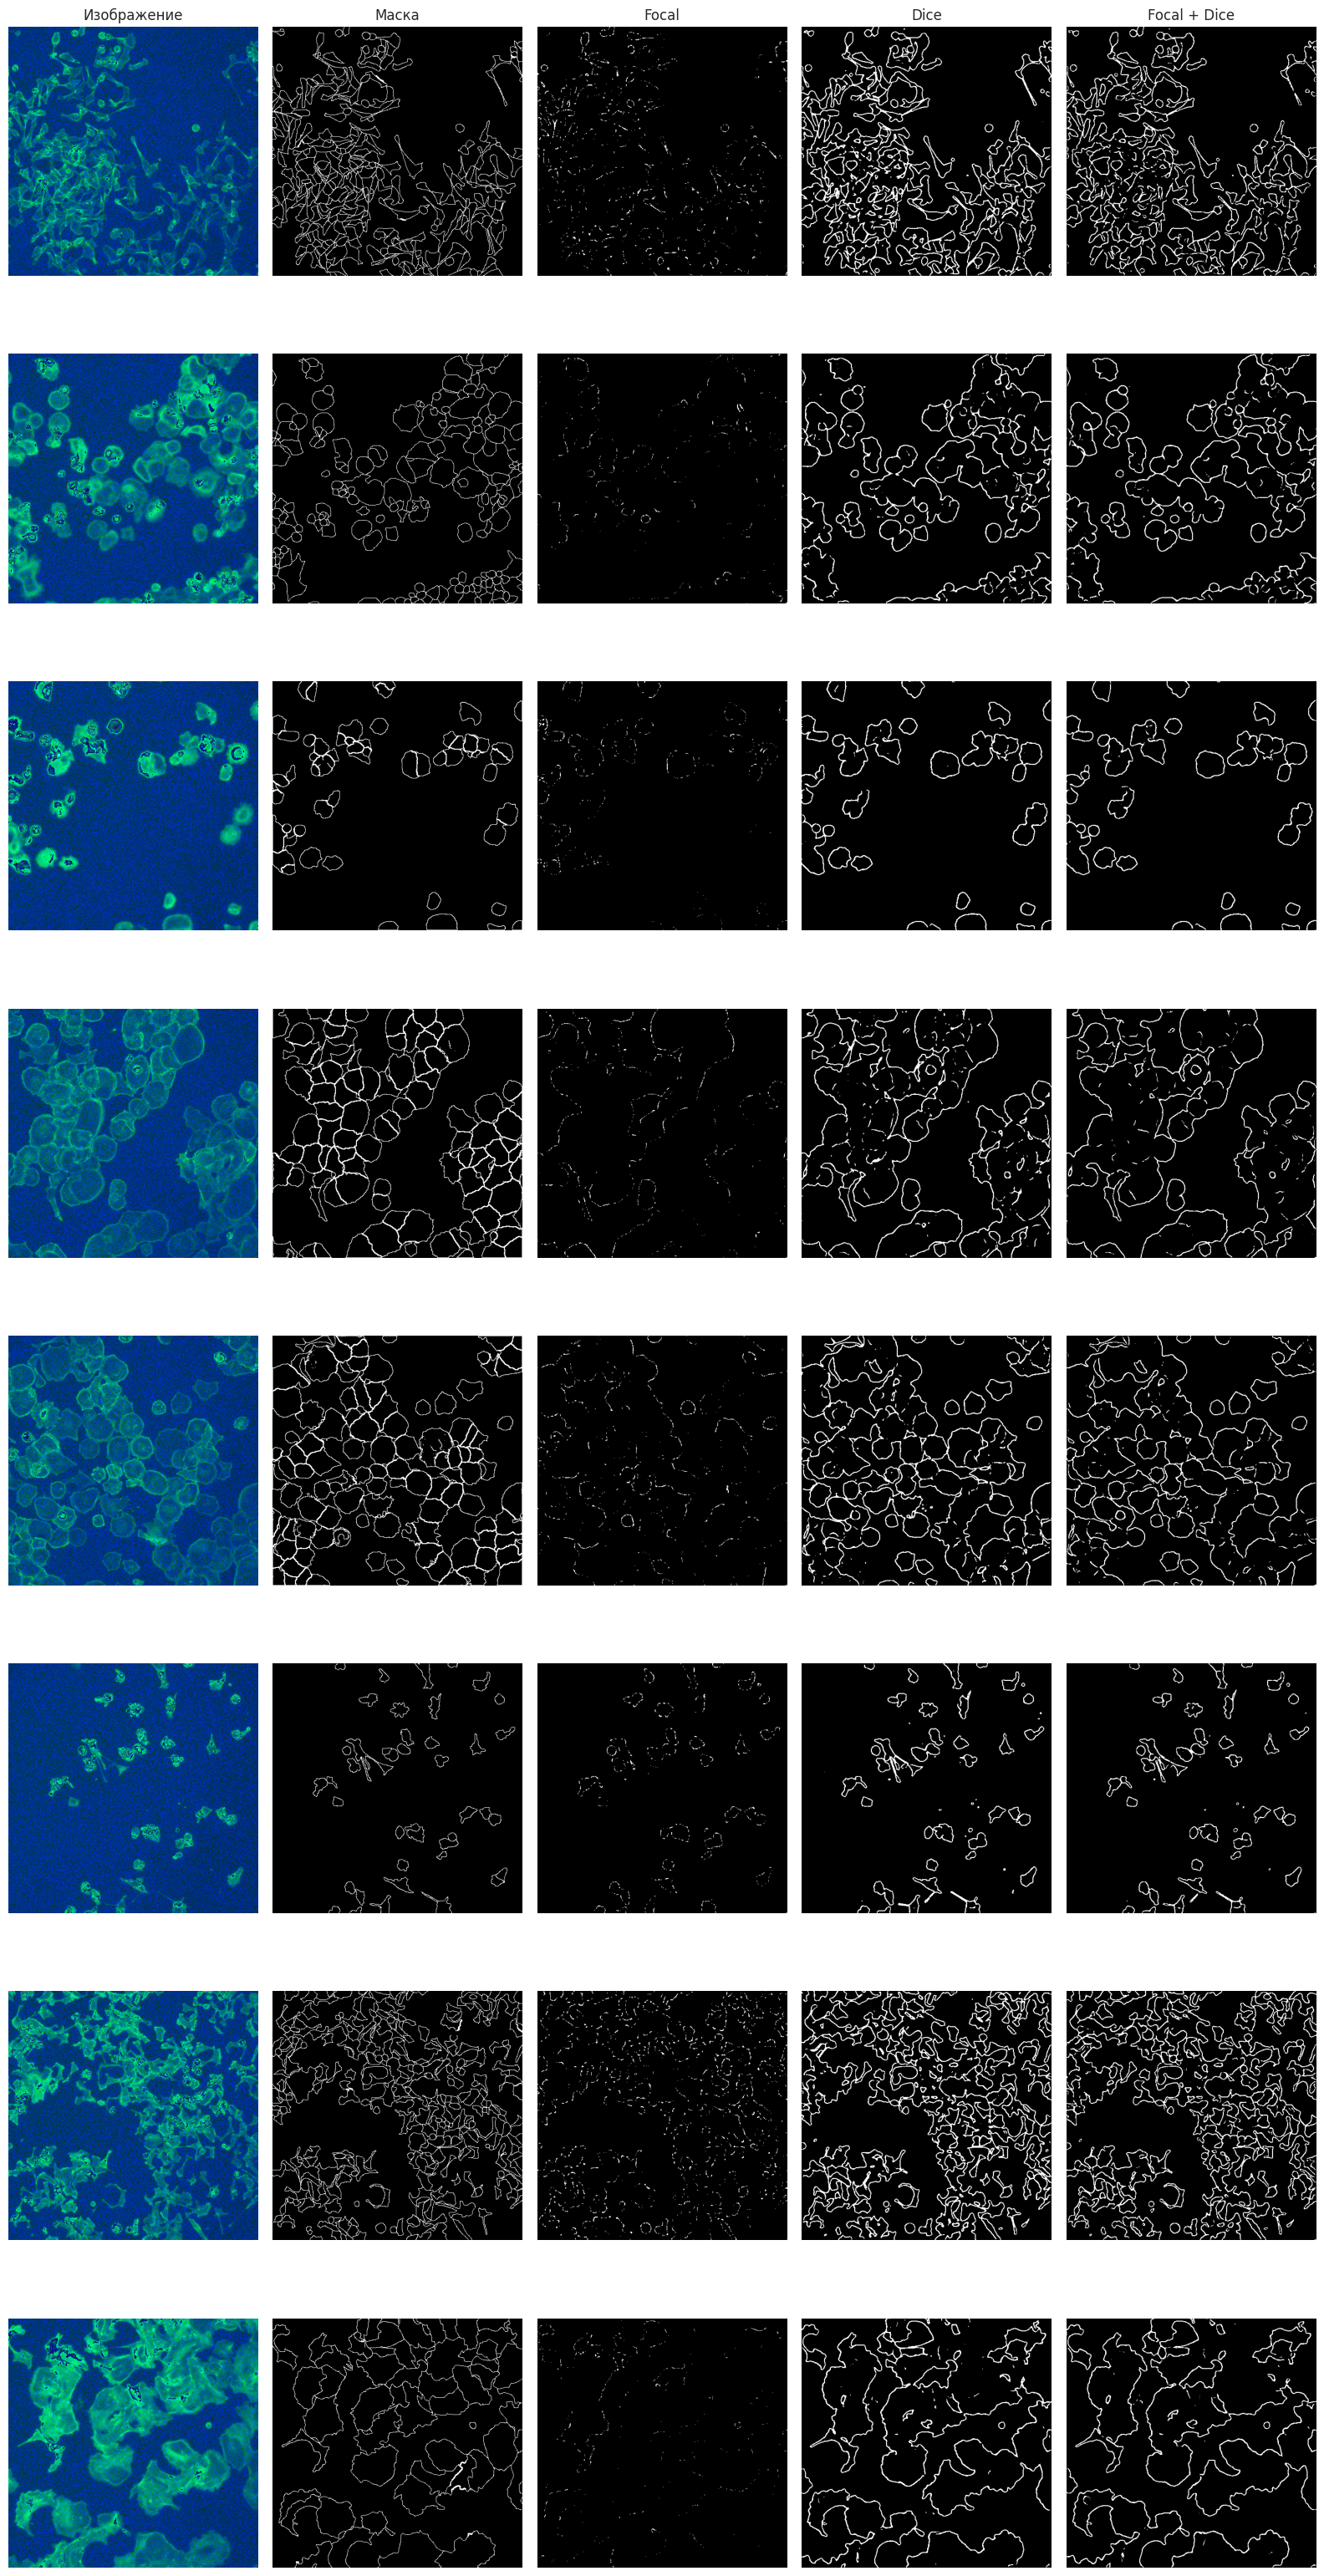

In [36]:
def visualize_predictions(model, model_dice, model_fd, dataset, n: int = 4):
    images, masks = dataset[0]
    images = images[:n]
    masks  = masks[:n]

    pred_focal = model.predict(images).argmax(axis=-1)
    pred_dice    = model_dice.predict(images).argmax(axis=-1)
    pred_fd    = model_fd.predict(images).argmax(axis=-1)

    fig, axes = plt.subplots(n, 5, figsize=(16, 4 * n))
    cols = ["Изображение", "Маска", "Focal", "Dice", "Focal + Dice"]

    for i in range(n):
        axes[i, 0].imshow(images[i])
        axes[i, 1].imshow(masks[i], cmap="gray")
        axes[i, 2].imshow(pred_focal[i], cmap="gray")
        axes[i, 3].imshow(pred_dice[i], cmap="gray")
        axes[i, 4].imshow(pred_fd[i], cmap="gray")

        for ax, col in zip(axes[i], cols):
            ax.set_title(col if i == 0 else "")
            ax.axis("off")

    plt.tight_layout()
    plt.savefig('vp.png')
    plt.show()

visualize_predictions(model, model_dice, model_fd, val_dataset, n = 8)

2026-06-01 09:04:01.287709: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 09:04:01.525014: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 09:04:02.133384: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 09:04:02.389453: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


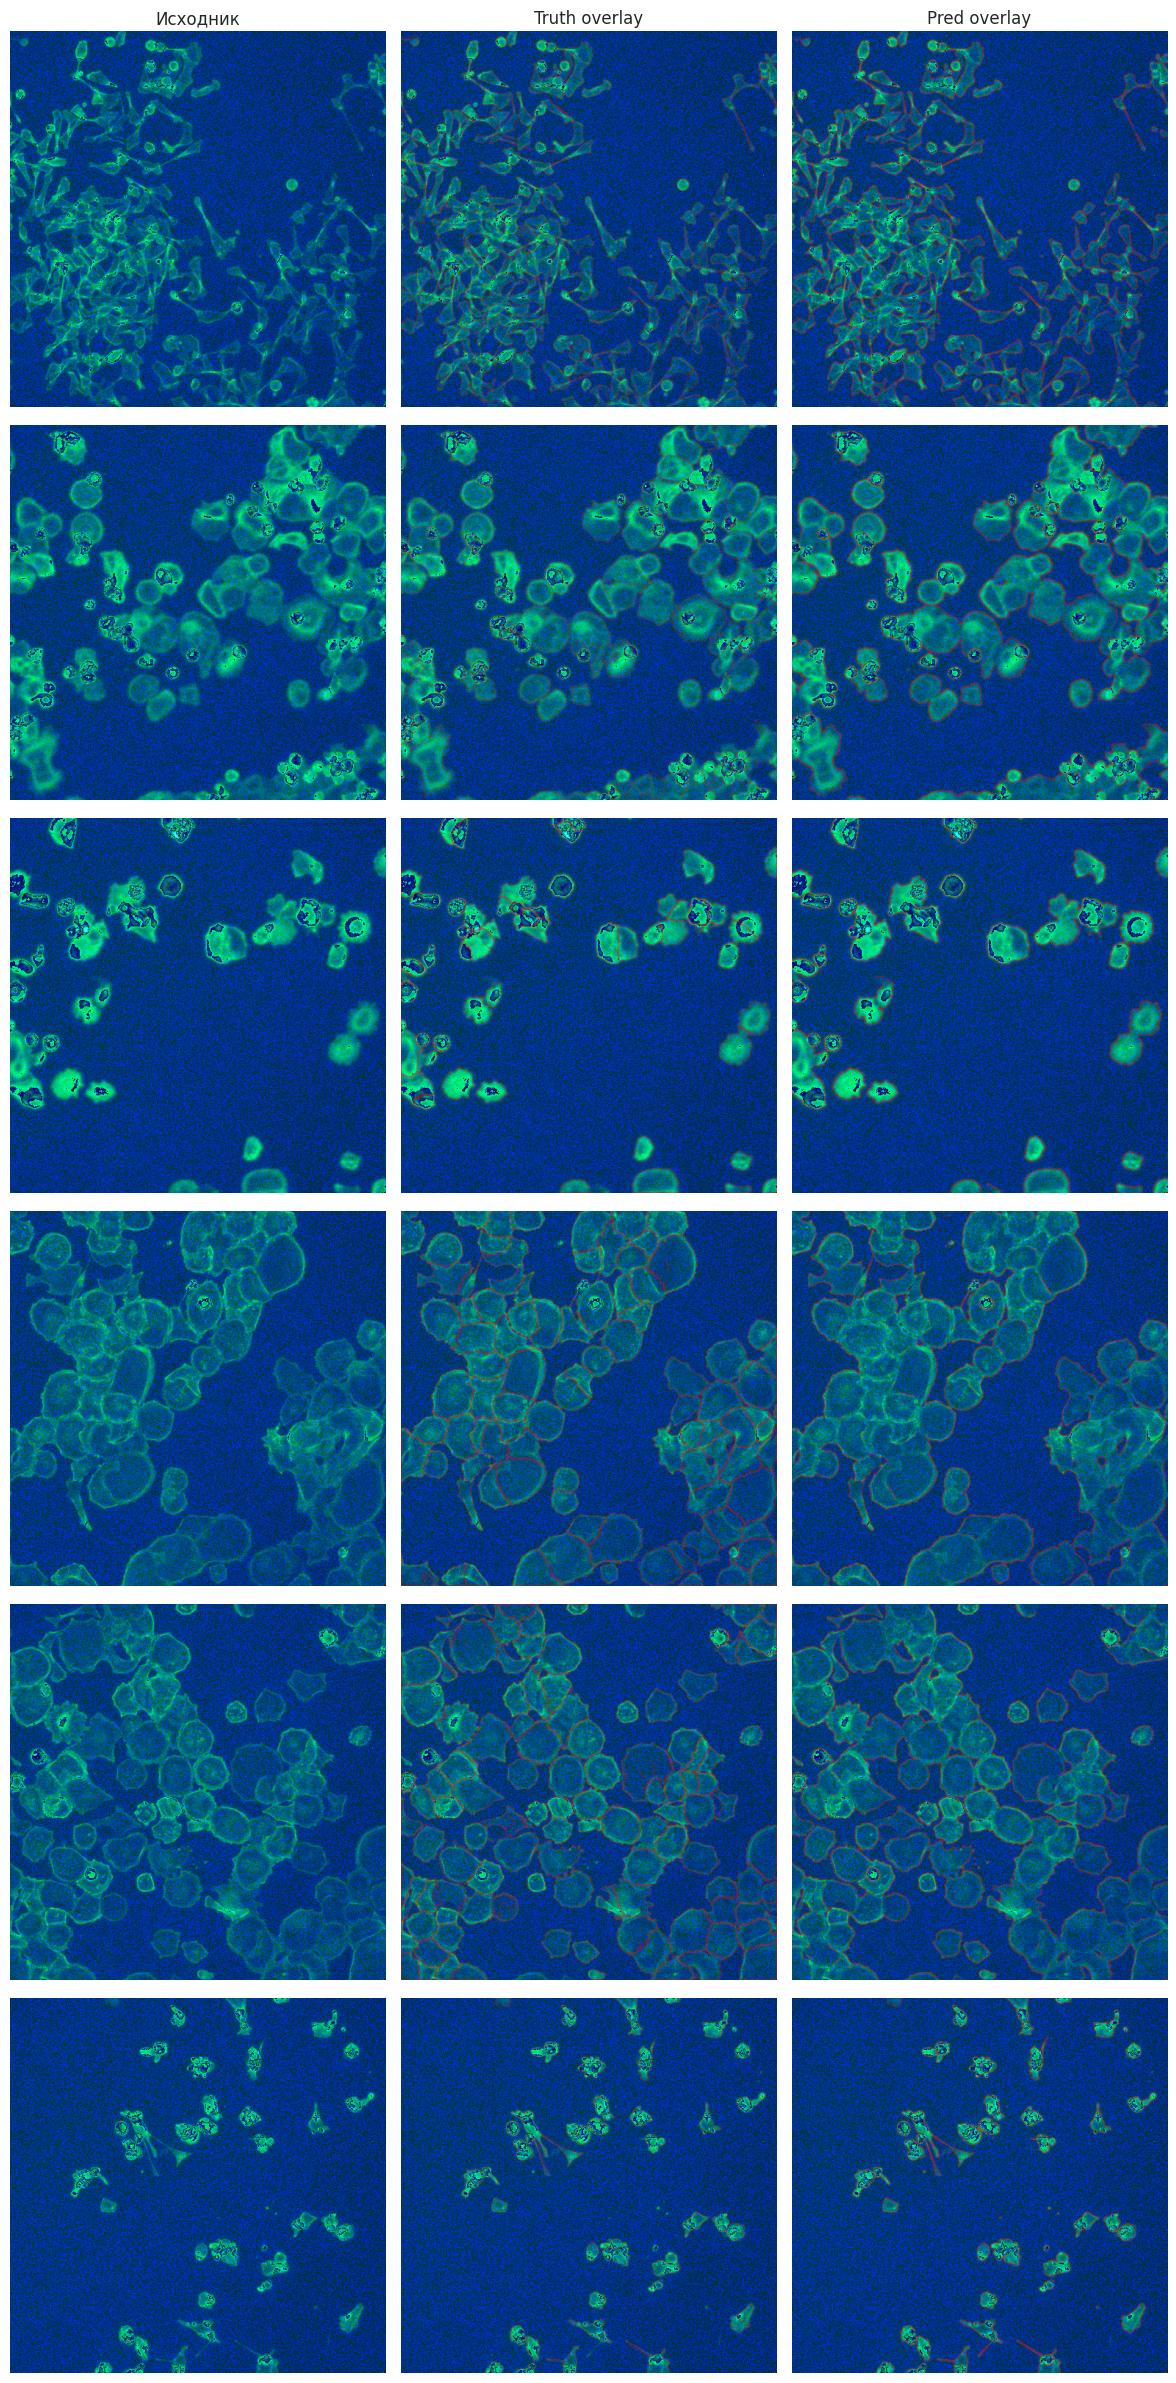

In [37]:
def visualize_overlay(model, dataset, n: int = 4, alpha: float = 0.4):
    images, masks = dataset[0]
    images = images[:n]
    masks  = masks[:n]

    preds = model.predict(images).argmax(axis=-1)

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    cols = ["Исходник", "Truth overlay", "Pred overlay"]

    for i in range(n):
        img = images[i].copy()

        gt_overlay = img.copy()
        gt_overlay[masks[i] == 1] = [1, 0, 0]
        gt_blend = (1 - alpha) * img + alpha * gt_overlay

        pred_overlay = img.copy()
        pred_overlay[preds[i] == 1] = [1, 0, 0]
        pred_blend = (1 - alpha) * img + alpha * pred_overlay

        axes[i, 0].imshow(img)
        axes[i, 1].imshow(np.clip(gt_blend, 0, 1))
        axes[i, 2].imshow(np.clip(pred_blend, 0, 1))

        for ax, col in zip(axes[i], cols):
            ax.set_title(col if i == 0 else "")
            ax.axis("off")

    plt.tight_layout()
    plt.savefig('overlay.png')
    plt.show()

visualize_overlay(model_fd, val_dataset, n = 6)